In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [2]:
# ================================
# 1. BACA DATA
# ================================
categories = pd.read_csv('categories.csv')
customers   = pd.read_csv('customers.csv')
orders      = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
products    = pd.read_csv('products.csv')
returns     = pd.read_csv('returns.csv')


In [3]:
# ================================
# 2. GABUNG DATA UNTUK ANALISIS
# ================================
# a. Gabung orders dengan order_items untuk mendapatkan revenue & product info
orders_items = orders.merge(order_items, on='order_id', how='left')

# b. Tambahkan informasi produk & kategori
orders_items = orders_items.merge(products[['product_id', 'category_id']], on='product_id', how='left')
orders_items = orders_items.merge(categories, on='category_id', how='left')

# c. Gabungkan returns untuk menandai order yang di-return
returns_with_order = returns.merge(order_items[['order_item_id', 'order_id']], on='order_item_id', how='left')
returned_order_ids = returns_with_order['order_id'].unique()
orders_items['is_returned'] = orders_items['order_id'].isin(returned_order_ids).astype(int)

# d. Buat dataset ringkasan per order (agregat)
order_summary = orders_items.groupby('order_id').agg(
    customer_id    = ('customer_id', 'first'),
    order_status   = ('order_status', 'first'),
    payment_method = ('payment_method', 'first'),
    total_revenue  = ('unit_price', 'sum'),
    total_items    = ('order_item_id', 'count'),
    is_returned    = ('is_returned', 'max')            # 1 jika salah satu item di-return
).reset_index()


FUNNEL UTAMA
                            Stage  Count  Conversion Rate
                     Total Orders   9000           100.00
                        Delivered   2940            32.67
Completed (Delivered & No Return)   1764            19.60
                         Returned   1176            13.07


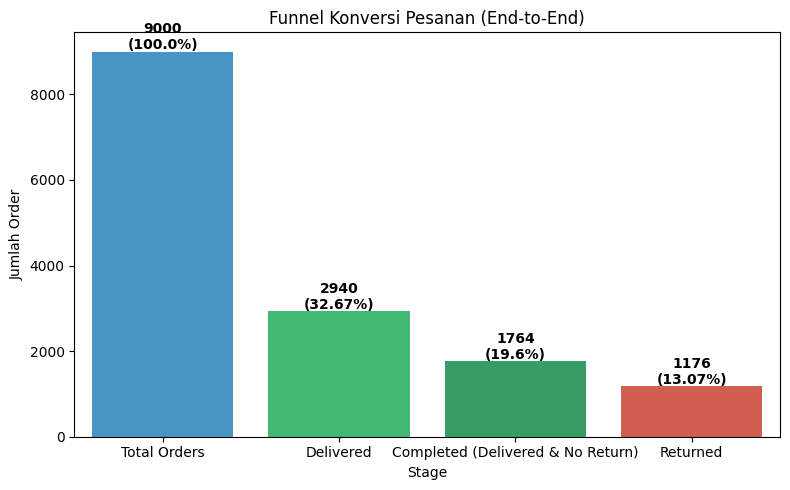

In [4]:
# ================================
# 3. FUNNEL UTAMA
# ================================
total_orders    = order_summary['order_id'].nunique()
delivered       = order_summary[order_summary['order_status'] == 'Delivered']
delivered_count = delivered['order_id'].nunique()
returned_count  = order_summary[order_summary['is_returned'] == 1]['order_id'].nunique()
completed_count = delivered_count - returned_count

funnel = pd.DataFrame({
    'Stage' : ['Total Orders', 'Delivered', 'Completed (Delivered & No Return)', 'Returned'],
    'Count' : [total_orders, delivered_count, completed_count, returned_count]
})
funnel['Conversion Rate'] = (funnel['Count'] / total_orders * 100).round(2)

print("="*60)
print("FUNNEL UTAMA")
print("="*60)
print(funnel.to_string(index=False))

plt.figure(figsize=(8,5))
ax = sns.barplot(data=funnel, x='Stage', y='Count', palette=['#3498db','#2ecc71','#27ae60','#e74c3c'])
plt.title('Funnel Konversi Pesanan (End-to-End)')
plt.ylabel('Jumlah Order')
for i, row in funnel.iterrows():
    ax.text(i, row['Count'] + 50, f"{row['Count']}\n({row['Conversion Rate']}%)",
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Distribusi Order Status:
Order Status  Count     %
  In Transit   3051 33.90
    Canceled   3009 33.43
   Delivered   2940 32.67


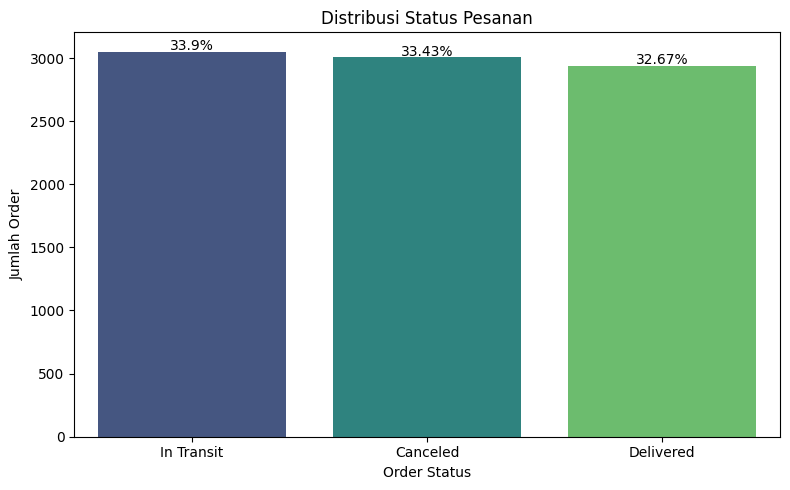

In [5]:
# ================================
# 4. ANALISIS DROP-OFF BERDASARKAN ORDER STATUS
# ================================
status_counts = order_summary['order_status'].value_counts().reset_index()
status_counts.columns = ['Order Status', 'Count']
status_counts['%'] = (status_counts['Count'] / total_orders * 100).round(2)

print("\nDistribusi Order Status:")
print(status_counts.to_string(index=False))

plt.figure(figsize=(8,5))
sns.barplot(data=status_counts, x='Order Status', y='Count', palette='viridis')
plt.title('Distribusi Status Pesanan')
plt.ylabel('Jumlah Order')
for i, row in status_counts.iterrows():
    plt.text(i, row['Count']+10, f"{row['%']}%", ha='center')
plt.tight_layout()
plt.show()


Cancel Rate per Payment Method:
  payment_method  total_orders  canceled_orders  cancel_rate
Cash on Delivery          2266              738        32.57
  Loyalty Points          2269              769        33.89
     Net Banking          2258              754        33.39
             UPI          2207              748        33.89


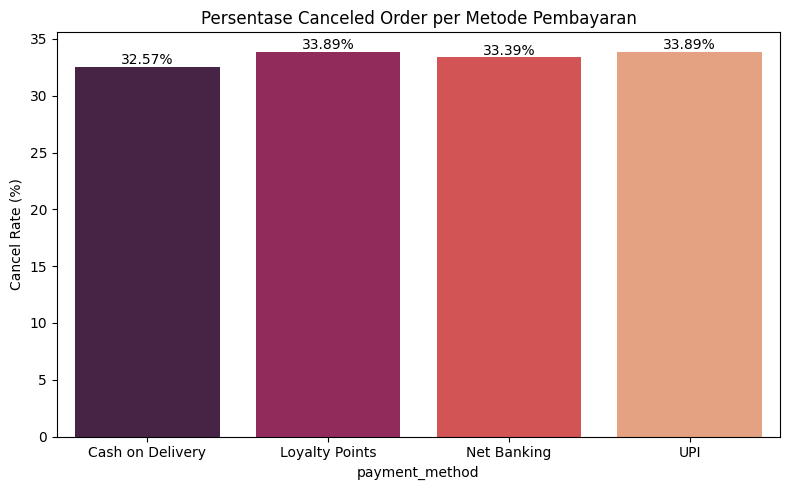

In [6]:
# ================================
# 5. ANALISIS CANCELATION RATE PER PAYMENT METHOD
# ================================
payment_cancel = order_summary.groupby('payment_method').agg(
    total_orders   = ('order_id', 'nunique'),
    canceled_orders= ('order_status', lambda x: (x == 'Canceled').sum())
).reset_index()
payment_cancel['cancel_rate'] = (payment_cancel['canceled_orders'] / payment_cancel['total_orders'] * 100).round(2)

print("\nCancel Rate per Payment Method:")
print(payment_cancel[['payment_method', 'total_orders', 'canceled_orders', 'cancel_rate']].to_string(index=False))

plt.figure(figsize=(8,5))
sns.barplot(data=payment_cancel, x='payment_method', y='cancel_rate', palette='rocket')
plt.title('Persentase Canceled Order per Metode Pembayaran')
plt.ylabel('Cancel Rate (%)')
for i, row in payment_cancel.iterrows():
    plt.text(i, row['cancel_rate']+0.2, f"{row['cancel_rate']}%", ha='center')
plt.tight_layout()
plt.show()



Return Rate per Product Category (hanya order delivered):
           category_name  total_orders  returned_orders  return_rate
        Beauty/Cosmetics           542              321        59.23
         Apparel/Fashion           788              457        57.99
             Electronics           597              342        57.29
                    Toys           840              470        55.95
        Food & Beverages           866              472        54.50
Home & Kitchen Furniture           672              364        54.17


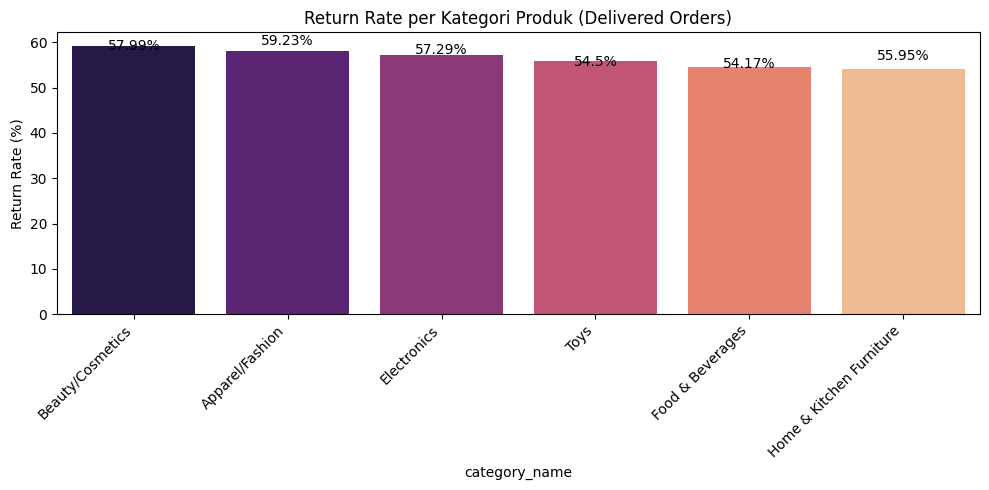

In [7]:
# ================================
# 6. ANALISIS RETURN RATE PER PRODUCT CATEGORY (SUDAH DIKOREKSI)
# ================================
# Ambil pasangan unik (order_id, category_name) dari pesanan Delivered
delivered_cat = (
    orders_items[orders_items['order_status'] == 'Delivered']
    [['order_id', 'category_name']]
    .drop_duplicates()
)

# Gabungkan dengan is_returned dari order_summary
delivered_cat = delivered_cat.merge(
    order_summary[['order_id', 'is_returned']], on='order_id', how='left'
)

# Hitung return rate per kategori
category_return = delivered_cat.groupby('category_name').agg(
    total_orders    = ('order_id', 'nunique'),
    returned_orders = ('is_returned', 'sum')
).reset_index()

category_return['return_rate'] = (
    category_return['returned_orders'] / category_return['total_orders'] * 100
).round(2)

print("\nReturn Rate per Product Category (hanya order delivered):")
print(category_return.sort_values('return_rate', ascending=False).to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(data=category_return.sort_values('return_rate', ascending=False),
            x='category_name', y='return_rate', palette='magma')
plt.title('Return Rate per Kategori Produk (Delivered Orders)')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45, ha='right')
for i, row in category_return.iterrows():
    plt.text(i, row['return_rate']+0.2, f"{row['return_rate']}%", ha='center')
plt.tight_layout()
plt.show()

In [8]:
# ================================
# 7. BOTTLENECK & INSIGHT
# ================================
print("\n" + "="*60)
print("BOTTLENECK & INSIGHT BISNIS")
print("="*60)

worst_payment = payment_cancel.loc[payment_cancel['cancel_rate'].idxmax()]
print(f"1. Metode pembayaran dengan cancel rate tertinggi: {worst_payment['payment_method']} ({worst_payment['cancel_rate']}%)")
print("   → Investigasi apakah ada kendala teknis atau user experience yang buruk pada metode ini.")

worst_cat = category_return.loc[category_return['return_rate'].idxmax()]
print(f"2. Kategori produk dengan return rate tertinggi: {worst_cat['category_name']} ({worst_cat['return_rate']}%)")
print("   → Cek kualitas produk, deskripsi di website, atau ekspektasi pelanggan.")

in_transit = order_summary[order_summary['order_status'] == 'In Transit']
if not in_transit.empty:
    print(f"3. Terdapat {len(in_transit)} order masih 'In Transit' – jika banyak, perlu evaluasi logistik.")
else:
    print("3. Semua order sudah memiliki status final (Delivered/Canceled).")

print("\nRekomendasi:")
print("- Optimalkan metode pembayaran dengan cancel rate tinggi (misal: perbaiki UI, beri notifikasi).")
print("- Untuk kategori dengan return tinggi, tambahkan deskripsi lebih detail dan foto produk yang akurat.")
print("- Pertimbangkan A/B testing untuk menguji perubahan di checkout page (lihat simulasi di bawah).")


BOTTLENECK & INSIGHT BISNIS
1. Metode pembayaran dengan cancel rate tertinggi: Loyalty Points (33.89%)
   → Investigasi apakah ada kendala teknis atau user experience yang buruk pada metode ini.
2. Kategori produk dengan return rate tertinggi: Beauty/Cosmetics (59.23%)
   → Cek kualitas produk, deskripsi di website, atau ekspektasi pelanggan.
3. Terdapat 3051 order masih 'In Transit' – jika banyak, perlu evaluasi logistik.

Rekomendasi:
- Optimalkan metode pembayaran dengan cancel rate tinggi (misal: perbaiki UI, beri notifikasi).
- Untuk kategori dengan return tinggi, tambahkan deskripsi lebih detail dan foto produk yang akurat.
- Pertimbangkan A/B testing untuk menguji perubahan di checkout page (lihat simulasi di bawah).


In [9]:
# ================================
# 8. SIMULASI A/B TESTING (PEMBAGIAN ACAK)
# ================================
np.random.seed(42)
order_summary['ab_group'] = np.random.choice(['A', 'B'], size=len(order_summary))

ab_metrics = order_summary.groupby('ab_group').agg(
    total_orders   = ('order_id', 'nunique'),
    delivered      = ('order_status', lambda x: (x == 'Delivered').sum())
).reset_index()
ab_metrics['delivery_rate'] = (ab_metrics['delivered'] / ab_metrics['total_orders'] * 100).round(2)

print("\n" + "="*60)
print("SIMULASI A/B TESTING (Random Assignment)")
print("="*60)
print(ab_metrics.to_string(index=False))

gA = order_summary[order_summary['ab_group'] == 'A']
gB = order_summary[order_summary['ab_group'] == 'B']
succ_A, n_A = (gA['order_status'] == 'Delivered').sum(), len(gA)
succ_B, n_B = (gB['order_status'] == 'Delivered').sum(), len(gB)
p_pool = (succ_A + succ_B) / (n_A + n_B)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
z = (succ_A/n_A - succ_B/n_B) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Z-score = {z:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("→ Ada perbedaan signifikan (tolak H0).")
else:
    print("→ Tidak ada perbedaan signifikan (gagal tolak H0).")
print("Kesimpulan: Karena pembagian acak, hasil tidak signifikan – sesuai harapan.")
print("Dalam eksperimen nyata, grup akan diberi perlakuan berbeda untuk mengukur dampaknya.")


SIMULASI A/B TESTING (Random Assignment)
ab_group  total_orders  delivered  delivery_rate
       A          4518       1474          32.63
       B          4482       1466          32.71
Z-score = -0.0845, p-value = 0.9327
→ Tidak ada perbedaan signifikan (gagal tolak H0).
Kesimpulan: Karena pembagian acak, hasil tidak signifikan – sesuai harapan.
Dalam eksperimen nyata, grup akan diberi perlakuan berbeda untuk mengukur dampaknya.
